# Confronto distribuzioni interazioni di neutrini in SHiP e SND@LHC

## Lettura dei dataset

Prima di tutto, apriamo i file di simulazione in SHiP e SND@LHC e costruiamo i dataset associati

In [1]:
import ROOT as r

In [2]:
%jsroot off

## SHiP simulation file

In [3]:
prepath = "/eos/user/a/aiuliano/public/sims_FairShip/GenieEvents_SHIP/GenieEvents_2026_03/2026_03_16_1year_allflavours/"
gstfileship = r.TFile.Open(prepath+"nu_1year_fluxhanae34.gst.root")
rootrackerfileship = r.TFile.Open(prepath+"nu_1year_fluxhanae34.rootracker.root")

gstship = gstfileship.Get("gst")
rootrackership = rootrackerfileship.Get("gRooTracker")

gstship.AddFriend(rootrackership)
dfship = r.RDataFrame(gstship)

## SNDLHC simulation file

In [4]:
prepath = "/eos/experiment/sndlhc/users/aiulian/Neutrino_MC_merged/sndlhc_13TeV_down_volTarget_100fb-1_SNDG18_02a_01_000/"
gstfilesndlhc = r.TFile.Open(prepath+"sndlhc_+volTarget_all_SNDG18_02a_01_000.0.gst.root")
rootrackerfilesndlhc = r.TFile.Open(prepath+"sndlhc_+volTarget_all_SNDG18_02a_01_000.0.rootracker.root")

gstsndlhc = gstfilesndlhc.Get("gst")
rootrackersndlhc = rootrackerfilesndlhc.Get("gRooTracker")

gstsndlhc.AddFriend(rootrackersndlhc)
dfsndlhc = r.RDataFrame(gstsndlhc)

## Binning logaritmico sulle x per visualizzare meglio le decadi di energia

In [5]:
import numpy as np
from array import array
# logaritmic binning parameters
# We want 10 bins per decade, and we want the bins to appear equally spaced on a logarithmic scale
nbinsE = 40
E_min = 1.     
E_max = 10000.

# Generate borders of logarithms bins
Ebin_borders = np.logspace(np.log10(E_min), np.log10(E_max), nbinsE + 1)

In [6]:
E_max = 4000.
Ebin_borders = Ebin_borders[Ebin_borders<E_max]
nbinsE = len(Ebin_borders)-1

In [7]:
# Conversion to c++
Ebin_borders_c = array('d', Ebin_borders)

## Energia neutrino incidente

In [8]:
hEship_nu = dfship.Histo1D(("hEship_nu","Energia neutrino incidente in SHiP",nbinsE,Ebin_borders_c),"Ev")

In [9]:
hEsndlhc_nu = dfsndlhc.Histo1D(("hEsndlhc_nu","Energia neutrino incidente in SNDLHC",nbinsE,Ebin_borders_c),"Ev")

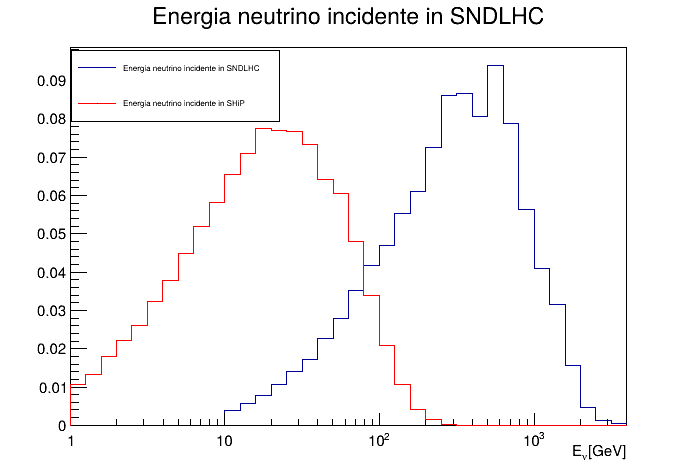

In [10]:
cE_nu = r.TCanvas()
r.gStyle.SetOptStat(0)
hEsndlhc_nu.GetXaxis().SetTitle("E_{#nu}[GeV]")
hEsndlhc_nu.Scale(1./hEsndlhc_nu.Integral())
hEsndlhc_nu.Draw("histo")
hEship_nu.Scale(1./hEship_nu.Integral())
hEship_nu.Draw("histo&&sames")
hEship_nu.SetLineColor(r.kRed)
cE_nu.SetLogx()
cE_nu.Draw()
cE_nu.BuildLegend(x1 = 0.3,y1 = 0.15, x2 = 0.3, y2 = 0.15)

## Energia leptone stato finale 

(per tutti i sapori, da notare che per interazioni di corrente neutra il leptone finale è un neutrino)

In [11]:
hEsndlhc_l = dfsndlhc.Histo1D(("hEsndlhc_l","Energia leptone stato finale in SNDLHC",nbinsE,Ebin_borders_c),"El")
hEship_l = dfship.Histo1D(("hEship_l","Energia leptone stato finale in SHiP",nbinsE,Ebin_borders_c),"El")

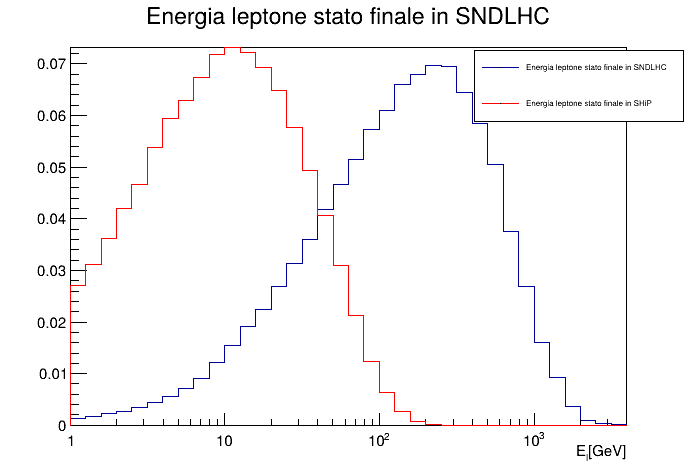

In [12]:
cE_l = r.TCanvas()
hEsndlhc_l.Scale(1./hEsndlhc_l.Integral())
hEsndlhc_l.GetXaxis().SetTitle("E_{l}[GeV]")
hEsndlhc_l.Draw("histo")
hEship_l.Scale(1./hEship_l.Integral())
hEship_l.Draw("histo&&sames")
hEship_l.SetLineColor(r.kRed)
cE_l.SetLogx()
cE_l.Draw()
cE_l.BuildLegend(x1 = 0.3,y1 = 0.15, x2 = 0.3, y2 = 0.15)

## Energia elettrone stato finale 

(solo per neutrini e antineutrini elettronici, qui selezioniamo le interazioni di corrente carica)

In [13]:
hEsndlhc_e = dfsndlhc.Filter("abs(neu)==12").Filter("cc").Histo1D(("hEsndlhc_l","Energia elettrone stato finale in SNDLHC",nbinsE,Ebin_borders_c),"El")
hEship_e = dfship.Filter("abs(neu)==12").Filter("cc").Histo1D(("hEship_l","Energia elettrone stato finale in SHiP",nbinsE,Ebin_borders_c),"El")

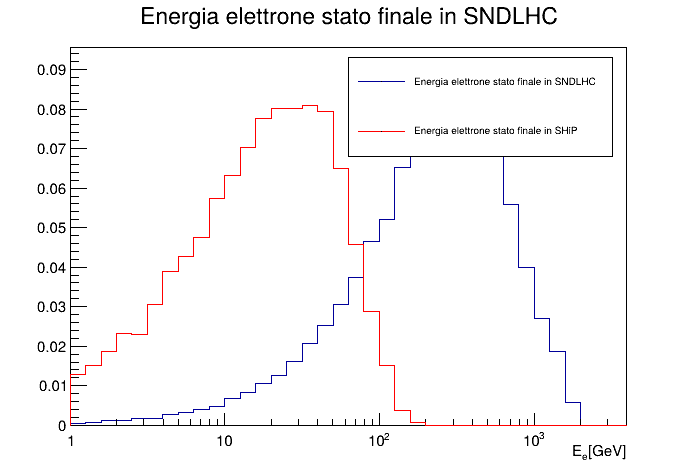

In [14]:
cE_e = r.TCanvas()
hEsndlhc_e.Scale(1./hEsndlhc_e.Integral())
hEsndlhc_e.GetXaxis().SetTitle("E_{e}[GeV]")
hEsndlhc_e.Draw("histo")
hEship_e.Scale(1./hEship_e.Integral())
hEship_e.Draw("histo&&sames")
hEship_e.SetLineColor(r.kRed)
cE_e.SetLogx()
cE_e.Draw()
cE_e.BuildLegend(x1 = 0.3,y1 = 0.15, x2 = 0.3, y2 = 0.15)

## Angolo muone stato finale
(solo per neutrini e antineutrini muonici, qui selezioniamo le interazioni di corrente carica)

In [15]:
dfship_numu = dfship.Filter("abs(neu)==14").Filter("cc")
dfship_thetamu = dfship_numu.Define("theta","atan(sqrt(pxl/pzl*pxl/pzl+pyl/pzl*pyl/pzl))")
hthetamu_ship = dfship_thetamu.Histo1D(("hthetamu_ship","Angolo di uscita del muone in SHiP",100,0,2.),"theta")

In [16]:
dfsndlhc_numu = dfsndlhc.Filter("abs(neu)==14").Filter("cc")
dfsndlhc_thetamu = dfsndlhc_numu.Define("theta","atan(sqrt(pxl/pzl*pxl/pzl+pyl/pzl*pyl/pzl))")
hthetamu_sndlhc = dfsndlhc_thetamu.Histo1D(("hthetamu_sndlhc","Angolo di uscita del muone in SNDLHC",100,0,2.),"theta")

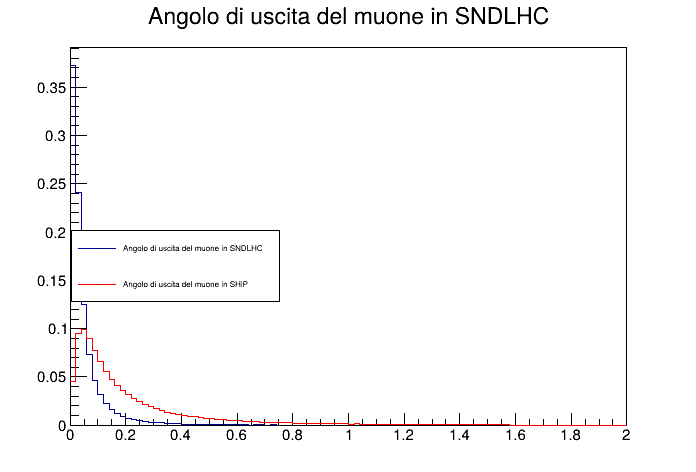

In [17]:
cTheta = r.TCanvas()
hthetamu_sndlhc.Scale(1./hthetamu_sndlhc.Integral())
hthetamu_sndlhc.GetXaxis().SetTitle("#theta_#mu[rad]")
hthetamu_sndlhc.Draw("histo")
hthetamu_ship.Scale(1./hthetamu_ship.Integral())
hthetamu_ship.GetXaxis().SetTitle("#theta_#mu[rad]")
hthetamu_ship.SetLineColor(r.kRed)
hthetamu_ship.Draw("histo&&sames")
cTheta.BuildLegend(x1 = 0.3,y1 = 0.15, x2 = 0.3, y2 = 0.15)
cTheta.Draw()